<a href="https://www.kaggle.com/code/lalit7881/healthcare-fraud-detection-eda?scriptVersionId=312625351" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nudratabbas/healthcare-fraud-detection-dataset/healthcare_fraud_detection.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nudratabbas/healthcare-fraud-detection-dataset/healthcare_fraud_detection.csv")

In [3]:
df.head()

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [4]:
df.tail()

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
9995,P0289,C0009995,79,Male,E78.5,71046,590.19,205.00,Private,2024-09-24,2,115,Internal Medicine,PA,Approved,1,2,Inpatient,1,3.0
9996,P0248,C0009996,66,Male,K21.9,93000,219.73,191.89,Self-Pay,2023-01-04,6,73,Orthopedics,IL,Approved,0,5,Inpatient,0,6.0
9997,P0122,C0009997,43,Female,F41.9,99213,505.24,447.94,Medicare,2024-06-30,6,59,Neurology,OH,Rejected,0,5,Emergency,1,0.0
9998,P0072,C0009998,39,Female,I10,93000,564.25,507.18,Medicare,2022-03-15,8,55,Cardiology,TX,Pending,0,5,Emergency,0,6.0
9999,P0137,C0009999,26,Male,J18.9,71046,564.52,563.74,Medicaid,2023-01-24,2,86,Neurology,CA,Approved,0,3,Outpatient,0,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

In [6]:
df.describe()

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [7]:
df.isnull().sum()

Provider_ID                                0
Claim_ID                                   0
Patient_Age                                0
Patient_Gender                             0
Diagnosis_Code                             0
Procedure_Code                             0
Claim_Amount                               0
Approved_Amount                            0
Insurance_Type                           350
Claim_Submission_Date                      0
Days_Between_Service_and_Claim             0
Number_of_Claims_Per_Provider_Monthly      0
Provider_Specialty                       350
Patient_State                              0
Claim_Status                               0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
Prior_Visits_12m                         350
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Provider_ID                               object
Claim_ID                                  object
Patient_Age                                int64
Patient_Gender                            object
Diagnosis_Code                            object
Procedure_Code                             int64
Claim_Amount                             float64
Approved_Amount                          float64
Insurance_Type                            object
Claim_Submission_Date                     object
Days_Between_Service_and_Claim             int64
Number_of_Claims_Per_Provider_Monthly      int64
Provider_Specialty                        object
Patient_State                             object
Claim_Status                              object
Is_Fraud                                   int64
Length_of_Stay                             int64
Visit_Type                                object
Chronic_Condition_Flag                     int64
Prior_Visits_12m                         float64
dtype: object

In [10]:
df.shape

(10000, 20)

In [11]:
df.columns

Index(['Provider_ID', 'Claim_ID', 'Patient_Age', 'Patient_Gender',
       'Diagnosis_Code', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount',
       'Insurance_Type', 'Claim_Submission_Date',
       'Days_Between_Service_and_Claim',
       'Number_of_Claims_Per_Provider_Monthly', 'Provider_Specialty',
       'Patient_State', 'Claim_Status', 'Is_Fraud', 'Length_of_Stay',
       'Visit_Type', 'Chronic_Condition_Flag', 'Prior_Visits_12m'],
      dtype='object')

In [12]:
df.nunique()

Provider_ID                                300
Claim_ID                                 10000
Patient_Age                                 95
Patient_Gender                               2
Diagnosis_Code                              10
Procedure_Code                               9
Claim_Amount                              9460
Approved_Amount                           9373
Insurance_Type                               4
Claim_Submission_Date                     1476
Days_Between_Service_and_Claim              30
Number_of_Claims_Per_Provider_Monthly      100
Provider_Specialty                           6
Patient_State                                8
Claim_Status                                 3
Is_Fraud                                     2
Length_of_Stay                               5
Visit_Type                                   3
Chronic_Condition_Flag                       2
Prior_Visits_12m                            13
dtype: int64

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Provider_ID                            10000 non-null  object        
 1   Claim_ID                               10000 non-null  object        
 2   Patient_Age                            10000 non-null  int64         
 3   Patient_Gender                         10000 non-null  object        
 4   Diagnosis_Code                         10000 non-null  object        
 5   Procedure_Code                         10000 non-null  int64         
 6   Claim_Amount                           10000 non-null  float64       
 7   Approved_Amount                        10000 non-null  float64       
 8   Insurance_Type                         9650 non-null   object        
 9   Claim_Submission_Date                  10000 non-null  datetim

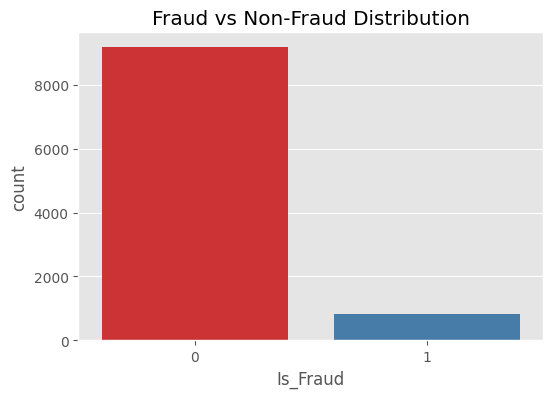

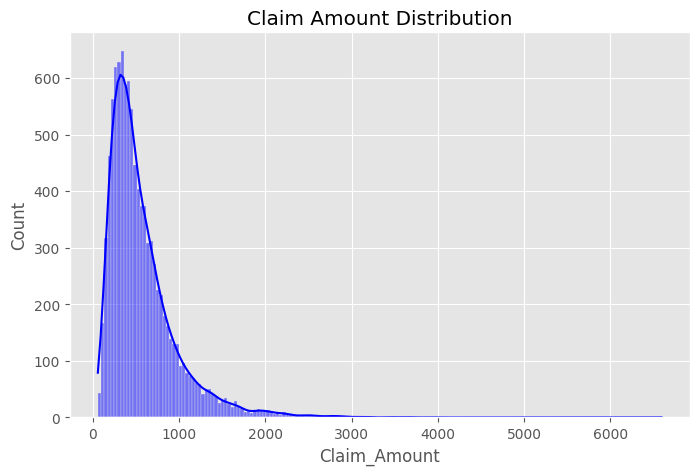

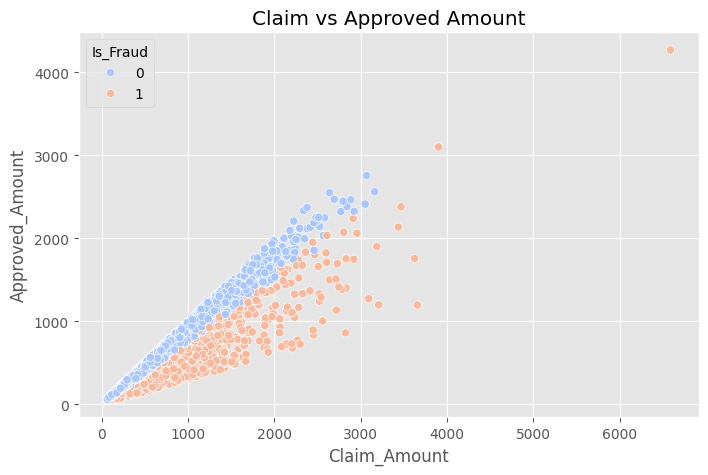

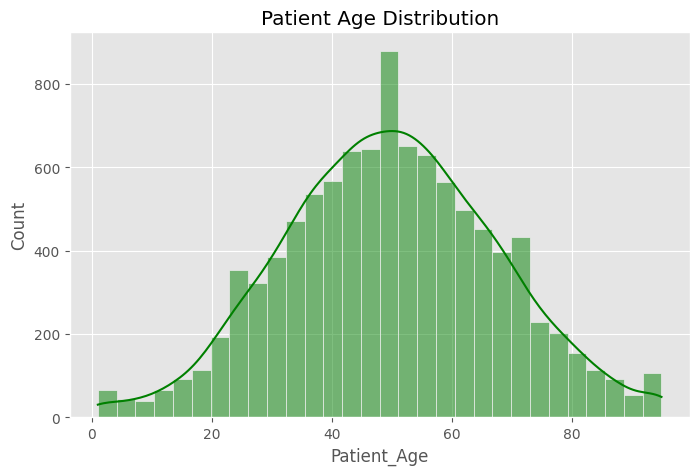

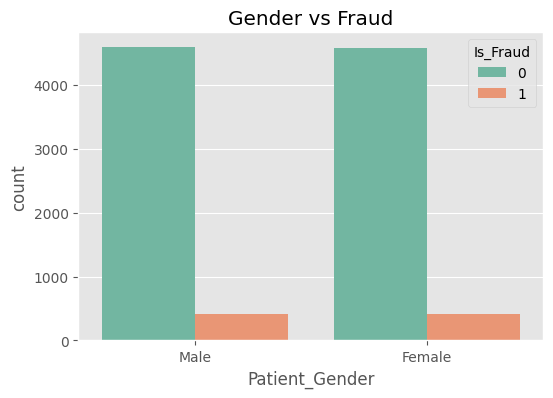

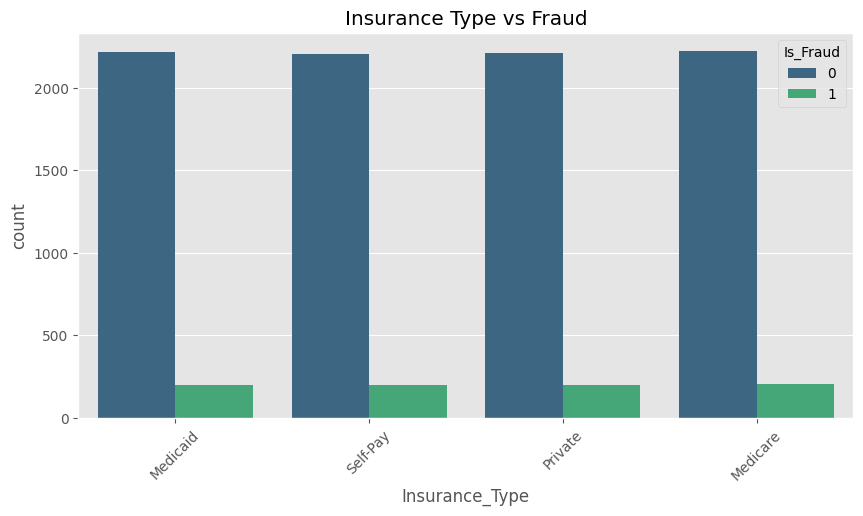

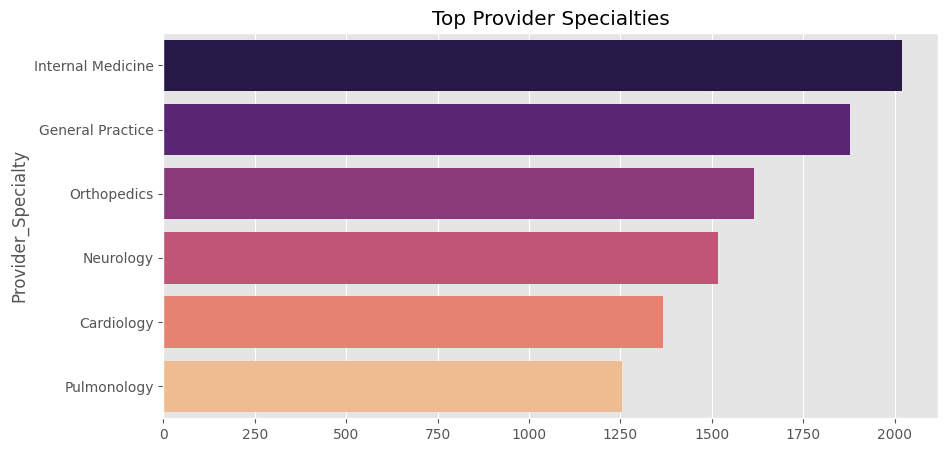

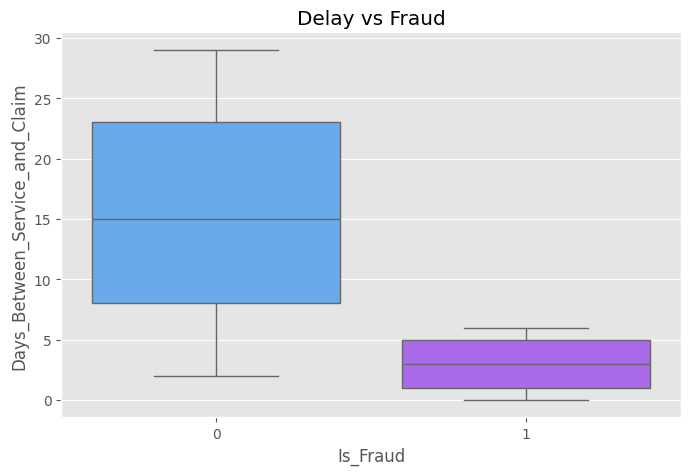

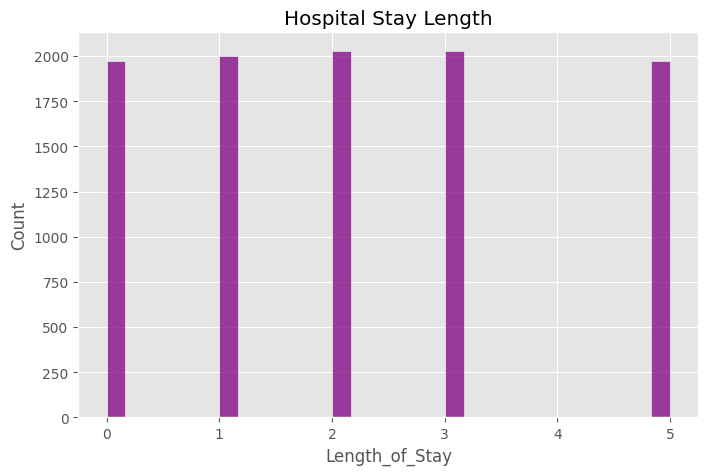

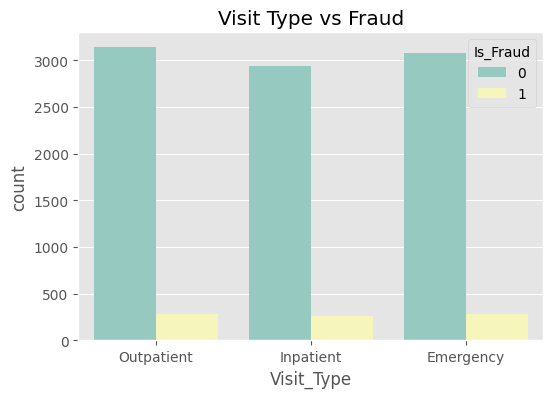

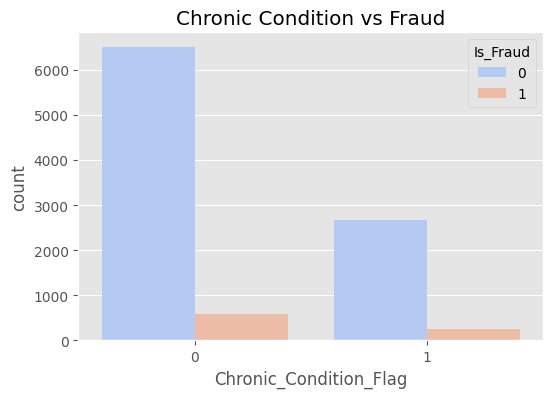

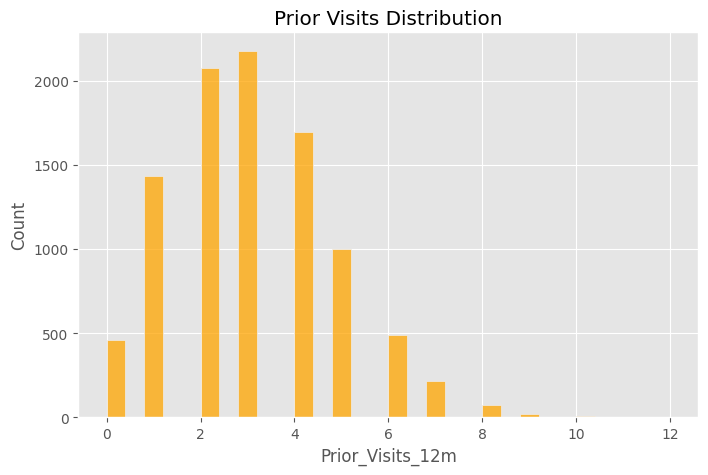

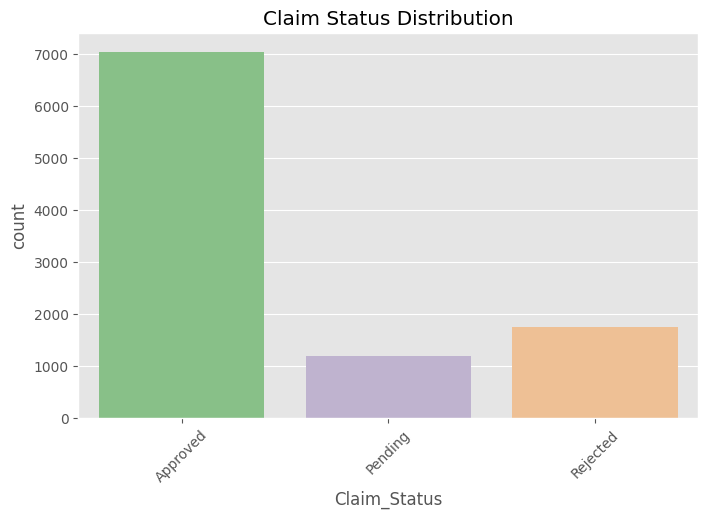

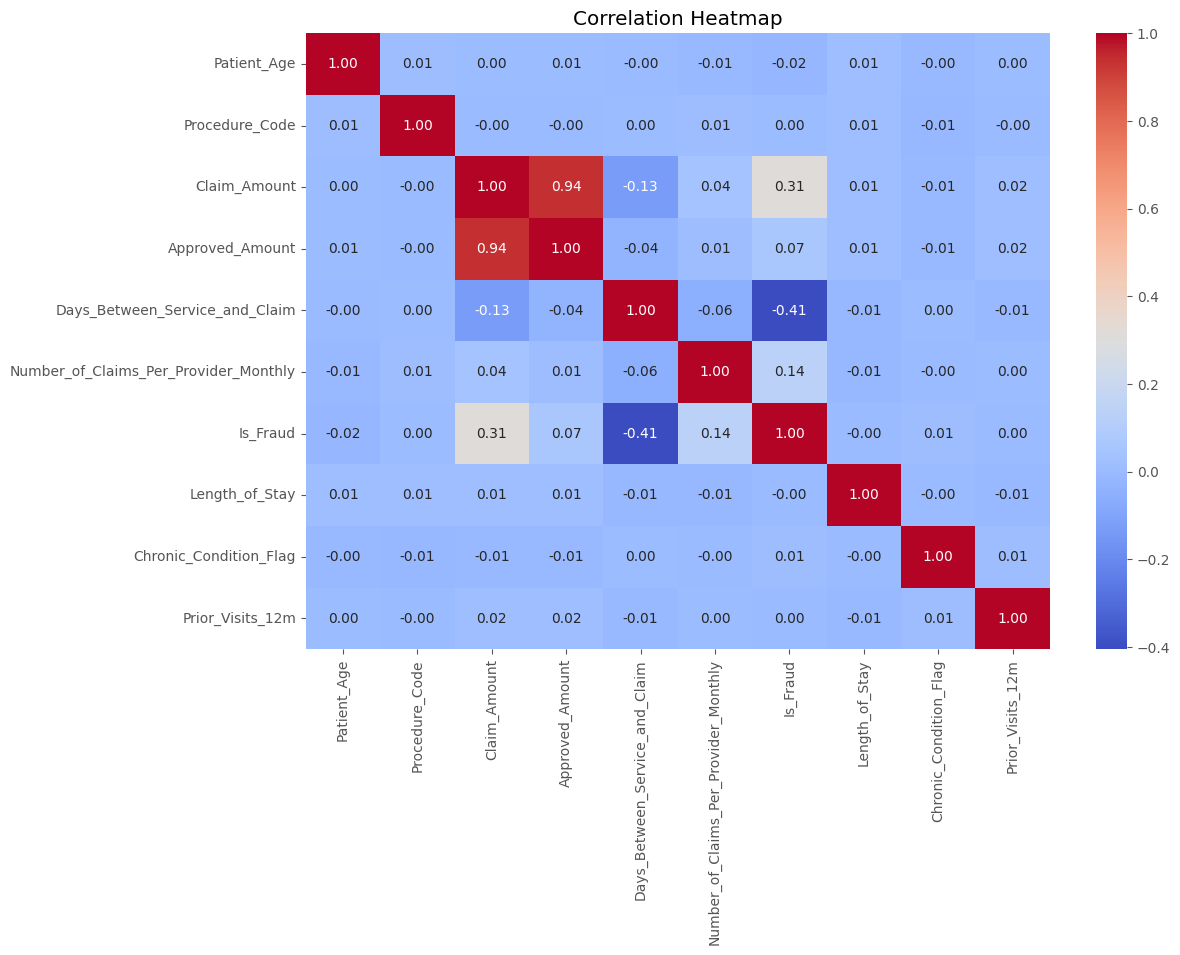

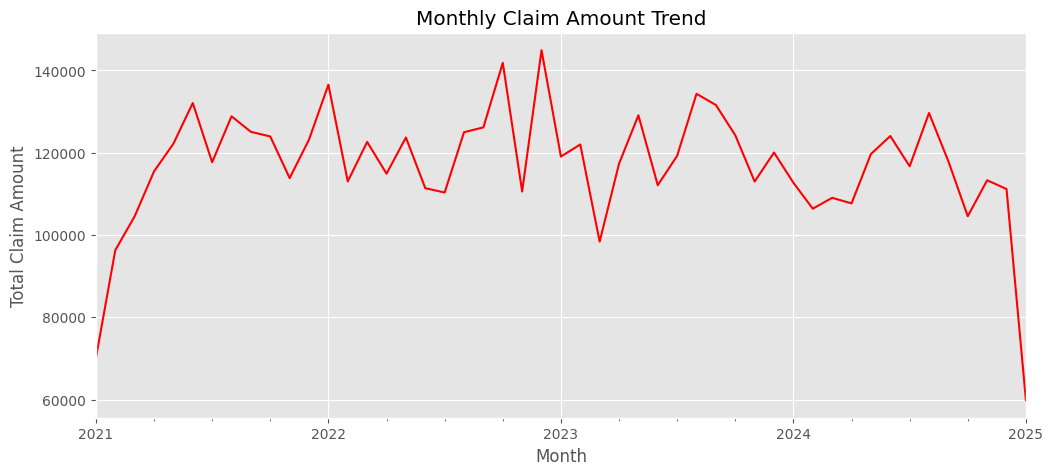

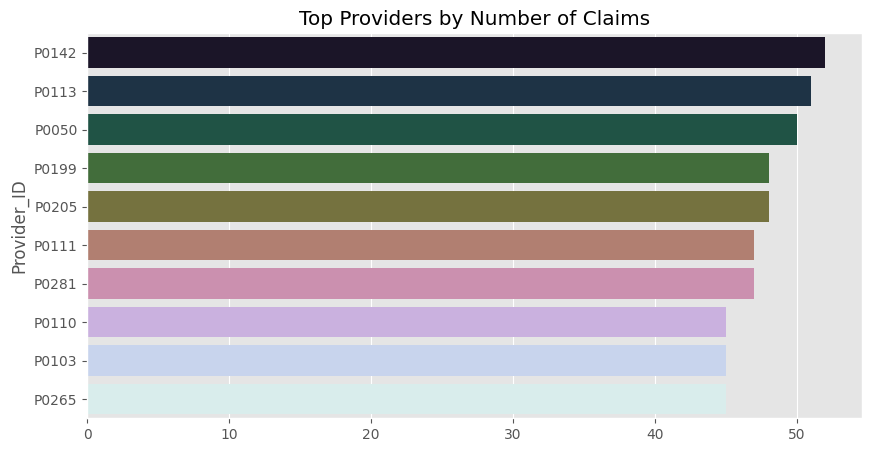

All visualizations generated successfully!


In [13]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STYLE
# ==============================
plt.style.use('ggplot')

# ==============================
# CLEANING
# ==============================
df.columns = df.columns.str.strip()

# Convert date safely
df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'], errors='coerce')

# Convert numeric columns safely
num_cols = ['Claim_Amount', 'Approved_Amount', 'Patient_Age',
            'Days_Between_Service_and_Claim', 'Length_of_Stay',
            'Prior_Visits_12m']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing critical values
df = df.dropna(subset=['Claim_Amount', 'Approved_Amount'])

# ==============================
# BASIC INFO
# ==============================
print(df.info())
print(df.describe())

# ==============================
# 1. FRAUD DISTRIBUTION
# ==============================
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Is_Fraud', palette='Set1')
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

# ==============================
# 2. CLAIM AMOUNT DISTRIBUTION
# ==============================
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Claim_Amount', kde=True, color='blue')
plt.title("Claim Amount Distribution")
plt.show()

# ==============================
# 3. APPROVED vs CLAIM AMOUNT (FIXED)
# ==============================
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,   # ✅ FIX
    x='Claim_Amount',
    y='Approved_Amount',
    hue='Is_Fraud',
    palette='coolwarm'
)
plt.title("Claim vs Approved Amount")
plt.show()

# ==============================
# 4. AGE DISTRIBUTION
# ==============================
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Patient_Age', bins=30, kde=True, color='green')
plt.title("Patient Age Distribution")
plt.show()

# ==============================
# 5. GENDER vs FRAUD
# ==============================
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Patient_Gender', hue='Is_Fraud', palette='Set2')
plt.title("Gender vs Fraud")
plt.show()

# ==============================
# 6. INSURANCE TYPE ANALYSIS
# ==============================
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Insurance_Type', hue='Is_Fraud', palette='viridis')
plt.xticks(rotation=45)
plt.title("Insurance Type vs Fraud")
plt.show()

# ==============================
# 7. PROVIDER SPECIALTY
# ==============================
plt.figure(figsize=(10,5))
top_specialties = df['Provider_Specialty'].value_counts().head(10)
sns.barplot(x=top_specialties.values, y=top_specialties.index, palette='magma')
plt.title("Top Provider Specialties")
plt.show()

# ==============================
# 8. DAYS BETWEEN SERVICE AND CLAIM
# ==============================
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Is_Fraud', y='Days_Between_Service_and_Claim', palette='cool')
plt.title("Delay vs Fraud")
plt.show()

# ==============================
# 9. LENGTH OF STAY
# ==============================
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Length_of_Stay', bins=30, color='purple')
plt.title("Hospital Stay Length")
plt.show()

# ==============================
# 10. VISIT TYPE ANALYSIS
# ==============================
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Visit_Type', hue='Is_Fraud', palette='Set3')
plt.title("Visit Type vs Fraud")
plt.show()

# ==============================
# 11. CHRONIC CONDITION IMPACT
# ==============================
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Chronic_Condition_Flag', hue='Is_Fraud', palette='coolwarm')
plt.title("Chronic Condition vs Fraud")
plt.show()

# ==============================
# 12. PRIOR VISITS
# ==============================
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Prior_Visits_12m', bins=30, color='orange')
plt.title("Prior Visits Distribution")
plt.show()

# ==============================
# 13. CLAIM STATUS
# ==============================
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Claim_Status', palette='Accent')
plt.xticks(rotation=45)
plt.title("Claim Status Distribution")
plt.show()

# ==============================
# 14. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 15. CLAIM TREND OVER TIME
# ==============================
df['Month'] = df['Claim_Submission_Date'].dt.to_period('M')

monthly_claims = df.groupby('Month')['Claim_Amount'].sum()

plt.figure(figsize=(12,5))
monthly_claims.plot(color='red')
plt.title("Monthly Claim Amount Trend")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount")
plt.show()

# ==============================
# 16. PROVIDER CLAIM LOAD
# ==============================
plt.figure(figsize=(10,5))
top_providers = df['Provider_ID'].value_counts().head(10)
sns.barplot(x=top_providers.values, y=top_providers.index, palette='cubehelix')
plt.title("Top Providers by Number of Claims")
plt.show()

# ==============================
# DONE
# ==============================
print("All visualizations generated successfully!")

## Feature engineering


===== Logistic Regression =====
Accuracy: 0.9865

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1834
           1       0.96      0.87      0.91       166

    accuracy                           0.99      2000
   macro avg       0.97      0.94      0.95      2000
weighted avg       0.99      0.99      0.99      2000


===== Random Forest =====
Accuracy: 0.9645

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1834
           1       0.94      0.61      0.74       166

    accuracy                           0.96      2000
   macro avg       0.95      0.81      0.86      2000
weighted avg       0.96      0.96      0.96      2000


===== Gradient Boosting =====
Accuracy: 0.985

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1834
           1       0.

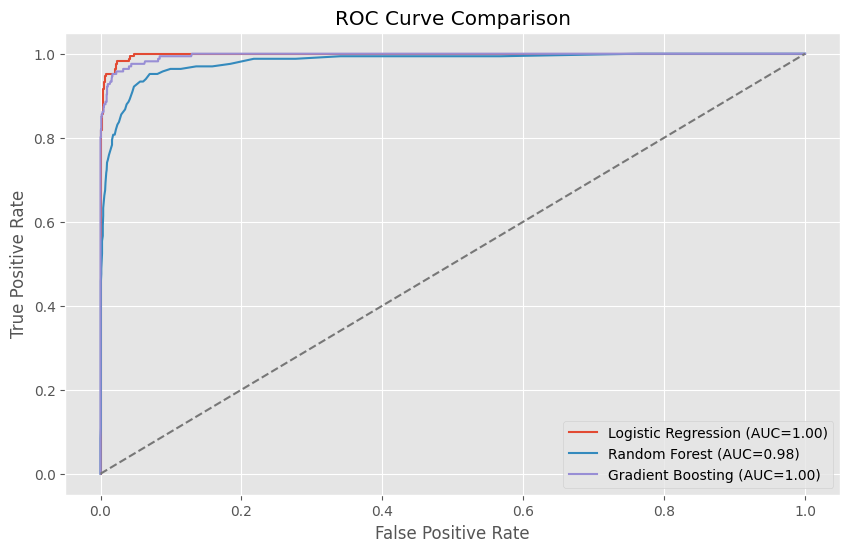


Best Model: Logistic Regression
Best Accuracy: 0.9865


In [14]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ==========================================
# BASIC CLEANING
# ==========================================
df.columns = df.columns.str.strip()

df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'], errors='coerce')

# Convert numeric columns
num_cols_fix = ['Claim_Amount','Approved_Amount','Patient_Age',
                'Days_Between_Service_and_Claim',
                'Number_of_Claims_Per_Provider_Monthly',
                'Length_of_Stay','Prior_Visits_12m']

for col in num_cols_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ==========================================
# FEATURE ENGINEERING
# ==========================================
df['Claim_Year'] = df['Claim_Submission_Date'].dt.year
df['Claim_Month'] = df['Claim_Submission_Date'].dt.month

df = df.drop(columns=['Claim_Submission_Date', 'Claim_ID'], errors='ignore')

# ==========================================
# TARGET
# ==========================================
target = 'Is_Fraud'

X = df.drop(columns=[target])
y = df[target]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# COLUMN TYPES
# ==========================================
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(exclude=np.number).columns

# ==========================================
# PIPELINES (🔥 FIX HERE)
# ==========================================
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # ✅ FIX
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # ✅ FIX
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# ==========================================
# MODELS
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# ==========================================
# TRAIN & EVALUATE
# ==========================================
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# ==========================================
# ROC CURVE
# ==========================================
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==========================================
# BEST MODEL
# ==========================================
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])

## Thank you...pls upvote!!!!!!!!